In [1]:
import time
from typing import List
import matplotlib.pyplot as plt

import torch
from torch import nn, Tensor
import torch.nn.functional as F
import math

import sys


In [2]:
class Summarizer(nn.Module):
    def __init__(self, embedding: int, bank: int = 1):
        super(Summarizer, self).__init__()
        self.weight = nn.Parameter(torch.randn(bank, 2 * embedding, embedding))
        self.bias = nn.Parameter(torch.randn(1, bank, 1, embedding))
        nn.init.xavier_normal_(self.weight)
        nn.init.xavier_normal_(self.bias)
        self.weight.data = self.weight.data * 0.1
        self.bias.data = self.bias.data * 0.1

    def forward(self, x: Tensor):
        return torch.einsum("b n s d, n d e -> b n s e", x, self.weight) + self.bias


class SingleVectorAttention(nn.Module):
    def __init__(self, embedding: int, heads: int):
        super().__init__()
        assert embedding % heads == 0, "Embedding dimension must be divisible by the number of attention heads."

        self.embedding = embedding
        self.heads = heads
        self.head_dim = embedding//heads
        self.scale = math.sqrt(self.head_dim)

        self.q = nn.Linear(embedding, embedding)
        self.k = nn.Linear(embedding, embedding)
        self.v = nn.Linear(embedding, embedding)
        self.out_proj = nn.Linear(embedding, embedding)

    def forward(self, x: Tensor) -> Tensor: # [batch, seq, log(seq), embedding]
        """
        Processes input using an attention mechanism to read from the logarithmic memory.

        This method is a placeholder for implementing an attention-based memory access
        scheme. It describes the intended interaction of an input `x` with the
        memory, using the logarithmic address in an attention mechanism.

        Args:
            x (Tensor): Input tensor of shape (batch_size, seq_len or 1, 1+ceil(log(seq_len))*bank, embedding_dim).

        Returns:
           Tensor: Output tensor of shape (batch_size, seq_len or 1, embedding_dim).
        """
        # Attention
        batch_size, seq, log_seq, embedding = x.shape

        mask = (x != 0) # mask zeros values to remain the same
        Q: Tensor = self.q(x) * mask
        K: Tensor = self.k(x[:, :, 0]) * (x[:, :, 0] != 0)
        V: Tensor = self.v(x) * mask

        Q = Q.view(batch_size, seq, log_seq, self.heads, self.head_dim).transpose(-2, -3)
        K = K.view(batch_size, seq, 1, self.heads, self.head_dim).transpose(-2, -3)
        V = V.view(batch_size, seq, log_seq, self.heads, self.head_dim).transpose(-2, -3) # [batch, seq, heads, log(seq), head_dim]

        scores = torch.einsum("...ij,...jk->...ik", Q, K.transpose(-1, -2)).squeeze(-1) # single vector attention #[batch, seq, heads, log(seq)]
        normalized_scores = scores / self.scale
        normalized_scores = torch.where(normalized_scores == 0, torch.full_like(normalized_scores, float('-inf')), normalized_scores) # mask attention
        attention_weights = torch.softmax(normalized_scores, dim=-1)

        attention_output = torch.einsum("...ki,...ij->...kj", attention_weights.unsqueeze(-2), V).squeeze(-2) # [batch, seq, heads, head_dim]
        attention_output = attention_output.reshape(batch_size, seq, embedding)
        output = self.out_proj(attention_output)

        return output

    def __call__(self, *args, **kwds) -> Tensor:
        return super().__call__(*args, **kwds)


class LogarithmicMemory(nn.Module):
    """
    A base module for exploring memory access with a logarithmic addressing scheme.

    This module provides a framework for experimenting with different methods
    of interacting with a memory structure. It defines a logarithmic memory
    pointer and several methods to access this memory, intended for research
    and experimentation purposes. It offers parallel, sequential, and attention-based
    methods of accessing the memory.
    """
    def __init__(self, embedding: int, heads: int = 1, bank: int = 1, parallelize=True):
        """
        Initializes the LogarithmicMemory module.
        """
        super().__init__()
        self.bank = bank
        self.parallelize = parallelize

        self.norm1 = nn.RMSNorm(embedding)
        self.norm2 = nn.RMSNorm(embedding)
        self.summarizer = Summarizer(embedding, bank)
        self.sva = SingleVectorAttention(embedding, heads)
        self.feedforward = nn.Sequential(
            nn.Linear(embedding, 4*embedding),
            nn.SiLU(),
            nn.Linear(4*embedding, embedding),
        )

        self.reset()

    def reset(self):
        """
        Resets the internal memory and the memory pointer.

        This function sets the internal memory (`self.memory`) to `None`,
        and the memory pointer (`self.ptr`) to 0. This allows for starting from
        a clean slate in each new experiment.
        """
        self.memory = None
        self.ptr = 0

    def summarize_table(self) -> List[bool]:
        """
        Summarizes a memory table based on a logarithmic addressing scheme.

        This function generates a logarithmic address by creating a sequence of
        binary differences between the current memory pointer (`self.ptr`) and
        the next one (`self.ptr + 1`). The memory pointer will also be incremented
        in the process.

        Returns:
            list: A list of boolean values representing the bit-wise differences between
                  consecutive memory pointers.
        """
        a, b = self.ptr, self.ptr+1
        self.ptr = b
        max_len = max(a.bit_length(), b.bit_length())
        return [(a ^ b) & (1 << i) != 0 for i in range(1, max_len)]

    def parallel(self, x: Tensor) -> Tensor: # [batch, seq, embedding]
        """
        Processes input in parallel based on the logarithmic memory addresses.

        This method is a placeholder for a parallel memory access scheme.
        It's intended to define how an input `x` is processed when interacting
        with the memory in a parallel fashion, using logarithmic addresses.

        Args:
            x (Tensor): Input tensor of shape (batch_size, seq_len, embedding_dim).

        Returns:
           Tensor: Output tensor of shape (batch_size, seq_len, 1+floor(log(seq_len))*bank, embedding_dim).
        """
        # Graph
        x_original = x
        x = x.unsqueeze(1).repeat(1, self.bank, 1, 1)
        batch_x, bank_x, seq_x, embed_x = x.shape

        x_last = x
        x_t = [x]
        for i in range(1, seq_x.bit_length()): # 1+floor(log(seq_x))
            # set length to be even and store shapes
            x_temp = x_last[:, :, :-1, :] if x_last.size(-2) % 2 == 1 else x_last
            batch, bank, seq, embedding = x_temp.shape

            # concatenate each two tokens and calculate the tree graph
            x_temp = x_temp.view(batch, bank, seq//2, 2*embedding)  # [batch, bank, seq/2, embedding*2]
            x_last = self.summarizer(x_temp)  # [batch, bank, seq/2, embedding]

            # sync shape of sequence by repeating.
            # handle zero padding values and extra cut length (extra non-power 2 index)
            x_temp = x_last.unsqueeze(-2).repeat(1, 1, 1, 2**i, 1).view(batch, bank, seq*2**(i-1), embedding) # [batch, bank, seq_x, embedding]

            exceed_shape = -(2**i-1)+(seq_x-seq*2**(i-1))
            exceed_shape = seq_x + 1 if exceed_shape == 0 else exceed_shape

            x_temp = torch.cat([
                torch.zeros(batch_x, bank_x, 2**i-1, embed_x, device=x.device),
                x_temp[:, :, :exceed_shape, :]
                ], dim=-2) # [batch, bank_x, seq_x, embedding]

            x_t.append(x_temp)

        if len(x_t) == 1:
            return x_original.unsqueeze(-2)

        x = torch.stack(x_t[1:], dim=-2) # [batch, bank, seq, log(seq)-1, embedding]
        x = x.permute(0, 2, 3, 1, 4).contiguous() # [batch, seq, log(seq)-1, bank, embedding]
        x = x.view(batch_x, seq_x, -1, embed_x) # [batch, seq, log(seq)*bank-1, embedding]
        x = torch.cat([x_original.unsqueeze(-2), x], dim=-2) # [batch, seq, log(seq)*bank, embedding]
        return x

    def sequential(self, x: Tensor) -> Tensor: # [batch, seq, embedding]
        """
        Processes input sequentially, writing to and reading from the memory based on
        logarithmic addressing.

        This method is a placeholder for a sequential memory access scheme.
        It defines how an input `x` interacts with the memory one step at a time,
        using logarithmic addresses.

        Args:
            x (Tensor): Input tensor of shape (batch_size, 1, embedding_dim).

        Returns:
           Tensor: Output tensor of shape (batch_size, 1, 1+floor(log(seq_len))*bank, embedding_dim).
        """
        # Memory
        x_original = x
        x = x.unsqueeze(1).repeat(1, self.bank, 1, 1) # [batch, bank, seq, embedding]
        batch_x, bank_x, seq_x, embed_x = x.shape

        new_memory = [x]
        for i, summarize in enumerate(self.summarize_table()):
            # summarize (update)
            if summarize:
                combination = self.summarizer(torch.cat([self.memory[i], new_memory[i]], dim=-1))
                new_memory.append(combination)

            # copy
            else:
                new_memory.append(self.memory[i + 1])
        self.memory = new_memory

        if len(new_memory) == 1:
            return x_original.unsqueeze(-2)

        x = torch.stack(new_memory[1:], dim=-2) # [batch, bank, seq, log(seq)-1, embedding]
        x = x.permute(0, 2, 3, 1, 4).contiguous() # [batch, seq, log(seq)-1, bank, embedding]
        x = x.view(batch_x, seq_x, -1, embed_x) # [batch, seq, log(seq)*bank-1, embedding]
        x = torch.cat([x_original.unsqueeze(-2), x], dim=-2) # [batch, seq, log(seq)*bank, embedding]
        return x

    def attention(self, x: Tensor) -> Tensor:
        return self.sva(x)

    def forward(self, x: Tensor) -> Tensor: # [batch_size, seq_len, embed_dim]
        """
        Forward pass that selects the desired memory processing method.

        This method is a placeholder for selecting a concrete memory processing
        scheme to be applied to input `x`. It's meant to choose from different
        access methods like `parallel` or `sequential`.

        Args:
            x (Tensor): Input tensor of shape (batch_size, seq_len, embedding_dim).

        Returns:
           Tensor: Output tensor of shape (batch_size, seq_len, embedding_dim).
        """
        x_ = self.norm1(x)
        x_ = self.parallel(x_) if self.parallelize else self.sequential(x_)
        x = x + self.attention(x_)
        x_ = self.norm2(x)
        x = x + self.feedforward(x_)
        return x

    def __call__(self, *args, **kwds) -> Tensor:
        return super().__call__(*args, **kwds)

Parallel:
seq_lengths: 256
Memory: 0.0036919116973876953
Attention: 0.0012364387512207031
seq_lengths: 512
Memory: 0.0027773380279541016
Attention: 0.001031637191772461
seq_lengths: 1024
Memory: 0.003077268600463867
Attention: 0.0010225772857666016
seq_lengths: 2048
Memory: 0.0035393238067626953
Attention: 0.0014846324920654297
seq_lengths: 4096
Memory: 0.0038940906524658203
Attention: 0.0015153884887695312
seq_lengths: 8192
Memory: 0.004515886306762695
Attention: 0.0018236637115478516
seq_lengths: 16384
Memory: 0.003810882568359375
Attention: 0.0033197402954101562
seq_lengths: 32768
Memory: 0.005042552947998047
Attention: 0.008776664733886719

Sequential:
seq_lengths: 16
Memory: 0.011381149291992188
Attention: 0.0031075477600097656
seq_lengths: 32
Memory: 0.020983219146728516
Attention: 0.004925727844238281
seq_lengths: 64
Memory: 0.04348134994506836
Attention: 0.011023283004760742
seq_lengths: 128
Memory: 0.08655023574829102
Attention: 0.028052091598510742
seq_lengths: 256
Memory: 0.

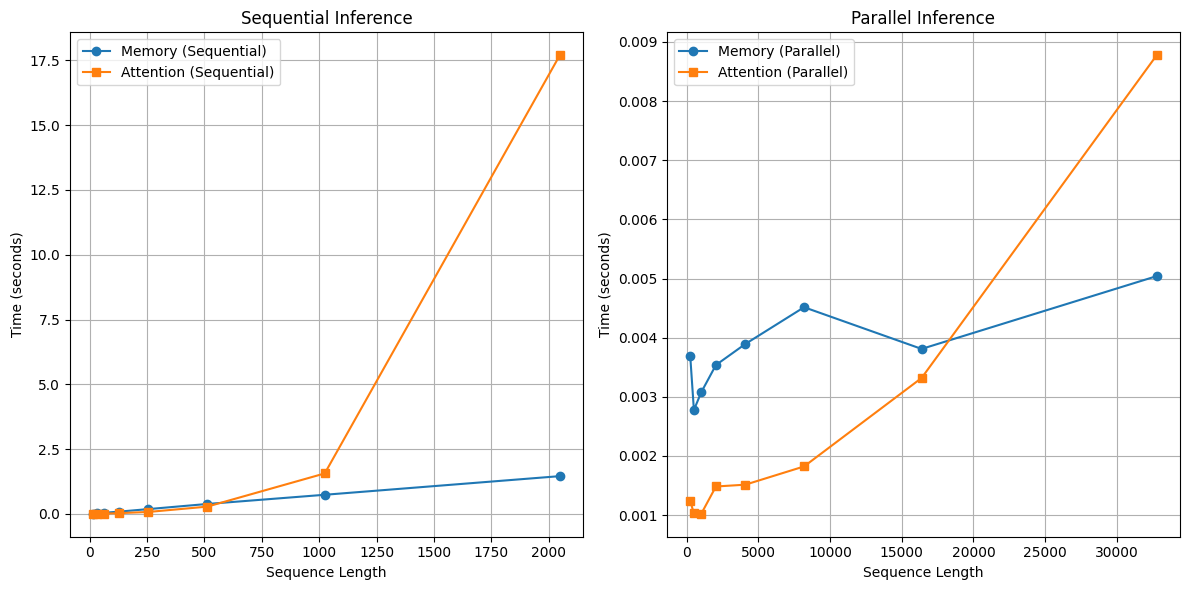

In [5]:
def masked_softmax(x): # x = [batch_size, seq_len, seq_len]
    upper_triangle_mask = torch.triu(torch.ones_like(x), diagonal=1).bool()
    x[upper_triangle_mask] = float('-inf')
    return F.softmax(x, dim=-1)

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert embed_dim % num_heads == 0
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads # wordEmbed 128 // numOfHeads 8 = 16
        self.key = nn.Linear(embed_dim, embed_dim)
        self.query = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim) # linear layer (W_O) to generate output

    def forward(self, x): # x = [batch_size, seq_len, embed_dim]
        batch_size, seq_len, embed_dim = x.size()
        K = self.key(x) # [batch_size, seq_len, embed_dim]
        Q = self.query(x) # [batch_size, seq_len, embed_dim]
        V = self.value(x) # [batch_size, seq_len, embed_dim]

        K = K.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2) # [batch_size, numOfHeads, seq_len, head_dim]
        Q = Q.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2) # [batch_size, numOfHeads, seq_len, head_dim]
        V = V.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2) # [batch_size, numOfHeads, seq_len, head_dim]


        attention_weight = F.softmax(torch.matmul(Q, K.transpose(-1, -2)) / (self.head_dim **0.5), dim=-1) #Q @ K.transpose(-1, -2)
        output = torch.matmul(attention_weight, V)  #output = attention_weight @ V
        output = output.transpose(1, 2).contiguous().view(batch_size, seq_len, embed_dim)
        return self.out_proj(output)


with torch.no_grad():
    # Parameters
    batch_size = 1
    embed_dim = 32
    heads = 1
    memory_banks = 1

    # Initialize modules
    memory = LogarithmicMemory(embed_dim, heads, memory_banks)
    attention = MultiHeadAttention(embed_dim, heads)

    # Data collection
    parallel_seq_lengths = [256 * (2 ** n) for n in range(8)]
    parallel_memory_times = []
    parallel_attention_times = []
    sequential_seq_lengths = [16 * (2 ** n) for n in range(8)]
    sequential_memory_times = []
    sequential_attention_times = []

    # Parallel Time
    memory.parallelize = True
    memory = memory.cuda()
    attention = attention.cuda()
    print("Parallel:")
    for seq_len in parallel_seq_lengths:
        print("seq_lengths:", seq_len)
        x = torch.randn(batch_size, seq_len, embed_dim).cuda()

        # Memory
        start = time.time()
        memory(x)
        parallel_memory_times.append(time.time() - start)
        print("Memory:", time.time() - start)
        memory.reset()

        # Attention
        start = time.time()
        attention(x)
        parallel_attention_times.append(time.time() - start)
        print("Attention:", time.time() - start)

    print()

    # Sequential Time
    memory.parallelize = False
    memory = memory.cpu()
    attention = attention.cpu()
    print("Sequential:")
    for seq_len in sequential_seq_lengths:
        print("seq_lengths:", seq_len)
        x = torch.randn(batch_size, seq_len, embed_dim)

        # Memory
        start = time.time()
        for i in range(x.size(1)):
            memory(x[:, i:i+1])
        sequential_memory_times.append(time.time() - start)
        print("Memory:", time.time() - start)
        memory.reset()

        # Attention
        start = time.time()
        for i in range(x.size(1)):
            attention(x[:, :i+1])
        sequential_attention_times.append(time.time() - start)
        print("Attention:", time.time() - start)

    # Plotting
    plt.figure(figsize=(12, 6))

    # Sequential inference
    plt.subplot(1, 2, 1)
    plt.plot(sequential_seq_lengths, sequential_memory_times, label='Memory (Sequential)', marker='o')
    plt.plot(sequential_seq_lengths, sequential_attention_times, label='Attention (Sequential)', marker='s')
    plt.xlabel('Sequence Length')
    plt.ylabel('Time (seconds)')
    plt.title('Sequential Inference')
    plt.legend()
    plt.grid()

    # Parallel inference
    plt.subplot(1, 2, 2)
    plt.plot(parallel_seq_lengths, parallel_memory_times, label='Memory (Parallel)', marker='o')
    plt.plot(parallel_seq_lengths, parallel_attention_times, label='Attention (Parallel)', marker='s')
    plt.xlabel('Sequence Length')
    plt.ylabel('Time (seconds)')
    plt.title('Parallel Inference')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()



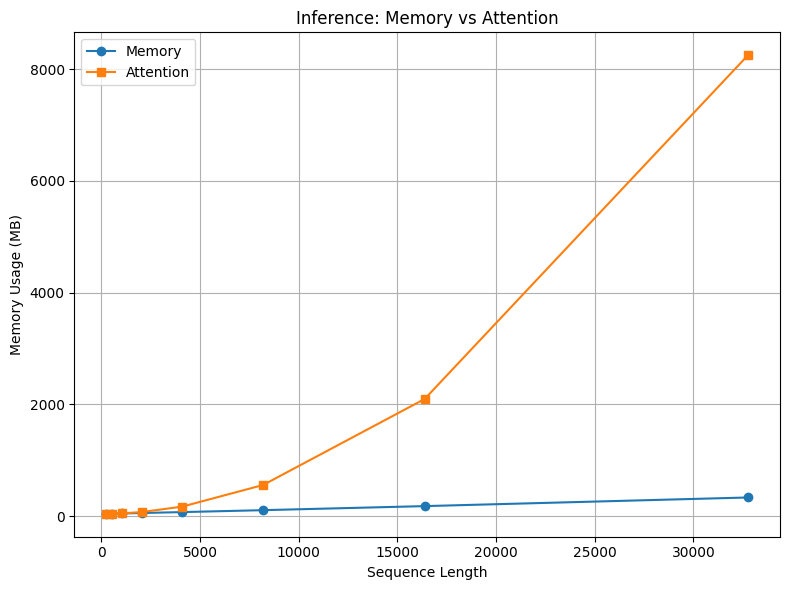

In [6]:
# Function to measure CPU memory usage
def get_cpu_memory():
    return sys.getsizeof(memory) + sys.getsizeof(attention)

# Data collection
seq_lengths = [256 * (2 ** n) for n in range(8)]
memory_usage = []
attention_usage = []

memory.parallelize = True
memory = memory.cuda()
attention = attention.cuda()

for seq_len in seq_lengths:
    x = torch.randn(batch_size, seq_len, embed_dim).cuda()

    # Memory usage for memory module
    torch.cuda.reset_peak_memory_stats()
    memory(x)
    memory_usage.append(torch.cuda.max_memory_allocated() / (1024 ** 2))  # In MB
    memory.reset()

    # Memory usage for attention module
    torch.cuda.reset_peak_memory_stats()
    attention(x)
    attention_usage.append(torch.cuda.max_memory_allocated() / (1024 ** 2))  # In MB

# Plotting
plt.figure(figsize=(8, 6))

# Plot memory and attention on the same plot
plt.plot(seq_lengths, memory_usage, label='Memory', marker='o')
plt.plot(seq_lengths, attention_usage, label='Attention', marker='s')

# Labels and title
plt.xlabel('Sequence Length')
plt.ylabel('Memory Usage (MB)')
plt.title('Inference: Memory vs Attention')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()